# 量化与剪枝：提升推理效率

> **难度：** 中级 | **时间：** 约 40 分钟

现代大语言模型拥有数十亿参数，以高精度浮点数存储。在推理阶段，解码过程是 **显存带宽受限的** —— GPU 大部分时间花在从 DRAM 加载权重，而非执行计算。这意味着 **更小的权重 = 更快的推理**，即使精度有微小损失。

**量化（Quantization）** 减少每个权重的比特数（例如 FP32 → INT8 → INT4），缩小显存占用并提高吞吐量。**剪枝（Pruning）** 直接移除权重，创建稀疏矩阵，跳过零值计算。

本 notebook 涵盖：
1. 权重量化基础 —— 对称 vs 非对称量化，scale 和 zero-point
2. 精度对比 —— FP32、FP16、INT8 和 INT4 各自能表示什么
3. GPTQ —— 基于 Hessian 矩阵的逐层量化与误差补偿
4. AWQ —— 激活感知的权重量化与显著通道缩放
5. 剪枝基础 —— 幅度剪枝，结构化 vs 非结构化
6. 精度-效率权衡 —— 困惑度 vs 每权重比特数

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../..")))

from mp_tutorial.inference import (
    quantize_symmetric, dequantize_symmetric,
    quantize_asymmetric, dequantize_asymmetric,
    simulate_gptq_error_compensation,
    magnitude_prune, structured_prune_rows,
)
from mp_tutorial.inference_viz import draw_quantization_comparison
from mp_tutorial.formatting import info_box, comparison_table
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)
from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

## 1. 权重量化基础

**量化** 将连续的浮点值映射为离散的整数集合。核心思想：不再以 32 位浮点数存储每个权重，而是以 8 位（甚至 4 位）整数加上少量元数据（scale 和 zero-point，由一组权重共享）来存储。

有两种主要方案：

| 方案 | 范围 | 公式 | 适用场景 |
|--------|-------|---------|----------|
| **对称量化** | $[-\alpha, \alpha]$ | $q = \text{round}(x / s)$，其中 $s = \max|x| / (2^{b-1}-1)$ | 权重（大致关于 0 对称） |
| **非对称量化** | $[\beta, \gamma]$ | $q = \text{round}(x/s + z)$，其中 $s = (\max x - \min x) / (2^b - 1)$ | 激活值（通常非负，如 ReLU 之后） |

**Scale**（$s$）在浮点范围和整数范围之间建立映射。**Zero-point**（$z$）对范围进行偏移，使得实数零映射到一个整数 —— 这对于保持零值权重的含义至关重要。

In [2]:
# Symmetric quantization: manual INT8 demo with a real weight tensor
torch.manual_seed(42)
W = torch.randn(4, 8) * 0.5  # simulate a small weight matrix

print("Original weight matrix (FP32):")
print(W.round(decimals=4))
print(f"\nRange: [{W.min().item():.4f}, {W.max().item():.4f}]")
print(f"Storage: {W.nelement()} elements x 4 bytes = {W.nelement() * 4} bytes")

Original weight matrix (FP32):
tensor([[ 0.9635,  0.7436,  0.4504, -1.0528,  0.3392, -0.6173, -0.0215, -0.8023],
        [-0.3761,  0.8244, -0.1962, -0.7018, -0.3639, -0.2797, -0.3844,  0.3812],
        [ 0.8212, -0.0798, -0.2487,  0.2198, -0.3791,  0.5392,  0.4004,  0.8403],
        [ 0.6396,  0.6482,  0.3052,  0.6674, -0.1158,  0.0209, -0.1258,  0.4299]])

Range: [-1.0528, 0.9635]
Storage: 32 elements x 4 bytes = 128 bytes


In [3]:
# Step-by-step symmetric quantization to INT8
bits = 8
qmin, qmax = -(2 ** (bits - 1)), 2 ** (bits - 1) - 1  # -128 to 127
abs_max = W.abs().max()
scale = abs_max / qmax

print(f"=== Symmetric INT8 Quantization ===")
print(f"Bit width: {bits} -> integer range [{qmin}, {qmax}]")
print(f"|max weight| = {abs_max.item():.4f}")
print(f"Scale = |max| / {qmax} = {scale.item():.6f}")
print(f"\nQuantize:   q = round(W / scale)")
print(f"Dequantize: W' = q * scale")

# Quantize
W_q, s = quantize_symmetric(W, bits=8)
print(f"\nQuantized (INT8):")
print(W_q)
print(f"\nStorage: {W_q.nelement()} elements x 1 byte + 1 scale = {W_q.nelement() + 4} bytes")
print(f"Compression: {W.nelement() * 4} -> {W_q.nelement() + 4} bytes = {W.nelement() * 4 / (W_q.nelement() + 4):.1f}x")

=== Symmetric INT8 Quantization ===
Bit width: 8 -> integer range [-128, 127]
|max weight| = 1.0528
Scale = |max| / 127 = 0.008289

Quantize:   q = round(W / scale)
Dequantize: W' = q * scale

Quantized (INT8):
tensor([[ 116,   90,   54, -127,   41,  -74,   -3,  -97],
        [ -45,   99,  -24,  -85,  -44,  -34,  -46,   46],
        [  99,  -10,  -30,   27,  -46,   65,   48,  101],
        [  77,   78,   37,   81,  -14,    3,  -15,   52]], dtype=torch.int8)

Storage: 32 elements x 1 byte + 1 scale = 36 bytes
Compression: 128 -> 36 bytes = 3.6x


In [4]:
# Dequantize and measure the error
W_deq = dequantize_symmetric(W_q, s)
error = W - W_deq

print("Dequantized (back to FP32):")
print(W_deq.round(decimals=4))
print(f"\nQuantization error (original - dequantized):")
print(error.round(decimals=6))
print(f"\nError statistics:")
print(f"  Max absolute error: {error.abs().max().item():.6f}")
print(f"  Mean absolute error: {error.abs().mean().item():.6f}")
print(f"  RMSE: {(error ** 2).mean().sqrt().item():.6f}")
print(f"  Relative error: {(error.norm() / W.norm()).item():.4%}")

Dequantized (back to FP32):
tensor([[ 0.9616,  0.7461,  0.4476, -1.0528,  0.3399, -0.6134, -0.0249, -0.8041],
        [-0.3730,  0.8207, -0.1989, -0.7046, -0.3647, -0.2818, -0.3813,  0.3813],
        [ 0.8207, -0.0829, -0.2487,  0.2238, -0.3813,  0.5388,  0.3979,  0.8372],
        [ 0.6383,  0.6466,  0.3067,  0.6714, -0.1161,  0.0249, -0.1243,  0.4311]])

Quantization error (original - dequantized):
tensor([[ 1.8810e-03, -2.4090e-03,  2.7280e-03,  0.0000e+00, -6.5800e-04,
         -3.8530e-03,  3.3350e-03,  1.7440e-03],
        [-3.0430e-03,  3.7050e-03,  2.7080e-03,  2.8000e-03,  7.9500e-04,
          2.1270e-03, -3.1050e-03, -9.2000e-05],
        [ 5.0200e-04,  3.0960e-03, -1.5000e-05, -4.0210e-03,  2.2490e-03,
          3.4400e-04,  2.5060e-03,  3.0750e-03],
        [ 1.2740e-03,  1.6340e-03, -1.4770e-03, -4.0770e-03,  2.4000e-04,
         -3.9890e-03, -1.4460e-03, -1.1220e-03]])

Error statistics:
  Max absolute error: 0.004077
  Mean absolute error: 0.002064
  RMSE: 0.002427
  Rel

In [5]:
# Asymmetric quantization — better for non-symmetric distributions
torch.manual_seed(42)
W_asym = torch.randn(4, 8) * 0.5 + 0.3  # shifted distribution (e.g., post-ReLU activations)

print(f"Original range: [{W_asym.min().item():.4f}, {W_asym.max().item():.4f}]")
print(f"Mean: {W_asym.mean().item():.4f} (not centered at 0)\n")

# Symmetric quantization wastes range for this distribution
W_q_sym, s_sym = quantize_symmetric(W_asym, bits=8)
W_deq_sym = dequantize_symmetric(W_q_sym, s_sym)
err_sym = (W_asym - W_deq_sym).pow(2).mean().sqrt()

# Asymmetric quantization uses the full range
W_q_asym, s_asym, z_asym = quantize_asymmetric(W_asym, bits=8)
W_deq_asym = dequantize_asymmetric(W_q_asym, s_asym, z_asym)
err_asym = (W_asym - W_deq_asym).pow(2).mean().sqrt()

print(f"Symmetric  INT8 -> RMSE = {err_sym.item():.6f}")
print(f"Asymmetric INT8 -> RMSE = {err_asym.item():.6f}")
print(f"\nAsymmetric is {err_sym.item() / err_asym.item():.1f}x more accurate for this shifted distribution.")
print(f"Asymmetric scale = {s_asym.item():.6f}, zero_point = {z_asym.item():.0f}")

Original range: [-0.7528, 1.2635]
Mean: 0.4090 (not centered at 0)

Symmetric  INT8 -> RMSE = 0.003246
Asymmetric INT8 -> RMSE = 0.002116

Asymmetric is 1.5x more accurate for this shifted distribution.
Asymmetric scale = 0.007907, zero_point = 95


**关键洞察：** 对称量化更简单（无 zero-point），适用于大致以零为中心的权重矩阵。非对称量化更适合均值非零的分布，例如 ReLU 之后的激活值或有偏移的权重分布。

在实践中，大多数纯权重量化方案（GPTQ、AWQ 等）对权重使用 **对称量化**，在需要时对激活值使用 **非对称量化**。

---
## 2. 精度对比：每种格式能表示什么？

不同数值格式能表示不同的值集合。精度越低意味着可表示的值越少，从而引入更多舍入误差 —— 但同时也意味着更小的显存占用。

| 格式 | 比特数 | 可表示的值数量 | 每权重内存 |
|--------|------|---------------------|-------------------|
| FP32 | 32 | 约 40 亿 | 4 字节 |
| FP16 | 16 | 约 65,536 | 2 字节 |
| INT8 | 8 | 256 | 1 字节 |
| INT4 | 4 | 16 | 0.5 字节 |

让我们可视化在固定范围内各种格式可表示的值。

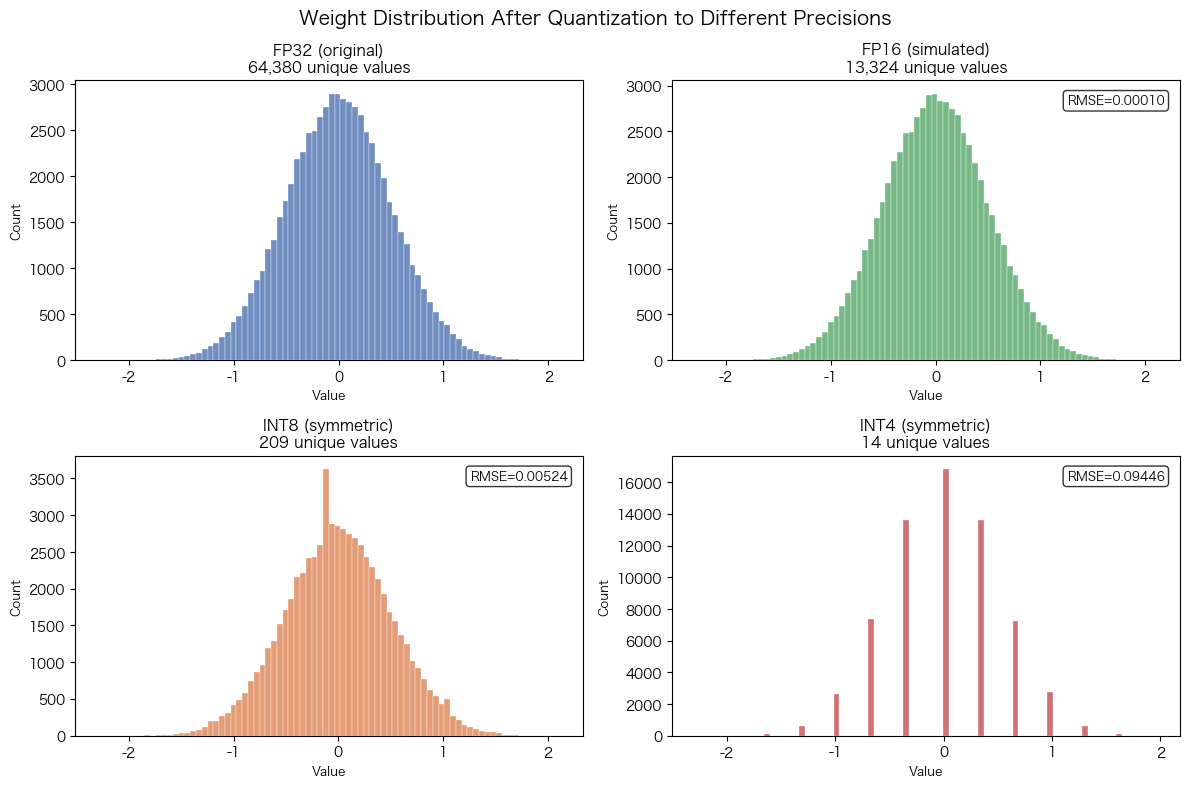

In [6]:
# Visualize representable values for different precisions
torch.manual_seed(42)
W_large = torch.randn(256, 256) * 0.5  # larger matrix for histogram

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Weight Distribution After Quantization to Different Precisions",
             fontsize=14, fontweight="bold")

configs = [
    ("FP32 (original)", W_large, "#4C72B0"),
    ("FP16 (simulated)", W_large.half().float(), "#55A868"),
    ("INT8 (symmetric)", None, "#DD8452"),
    ("INT4 (symmetric)", None, "#C44E52"),
]

# Quantize at different bit widths
W_q8, s8 = quantize_symmetric(W_large, bits=8)
W_deq8 = dequantize_symmetric(W_q8, s8)
configs[2] = ("INT8 (symmetric)", W_deq8, "#DD8452")

W_q4, s4 = quantize_symmetric(W_large, bits=4)
W_deq4 = dequantize_symmetric(W_q4, s4)
configs[3] = ("INT4 (symmetric)", W_deq4, "#C44E52")

for ax, (label, tensor, color) in zip(axes.flat, configs):
    vals = tensor.detach().numpy().flatten()
    n_unique = len(np.unique(np.round(vals, decimals=6)))
    ax.hist(vals, bins=80, color=color, alpha=0.8, edgecolor="white", linewidth=0.3)
    ax.set_title(f"{label}\n{n_unique:,} unique values", fontsize=11, fontweight="bold")
    ax.set_xlabel("Value", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    rmse = np.sqrt(np.mean((W_large.numpy().flatten() - vals) ** 2))
    if "FP32" not in label:
        ax.text(0.97, 0.95, f"RMSE={rmse:.5f}", transform=ax.transAxes,
                ha="right", va="top", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

In [7]:
# Quantization error impact on matrix multiplication
# This is what matters: does quantized W @ x ≈ original W @ x?
torch.manual_seed(42)
W_mm = torch.randn(128, 64) * 0.5  # weight matrix
x = torch.randn(64, 1)             # input activation

y_exact = W_mm @ x  # FP32 result

print(f"{'Precision':<20} | {'Output RMSE':>12} | {'Relative Error':>14} | {'Memory':>10}")
print("-" * 65)

for label, bits in [("FP32 (baseline)", 32), ("FP16", 16), ("INT8", 8), ("INT4", 4)]:
    if bits == 32:
        y_q = y_exact
        mem = W_mm.nelement() * 4
    elif bits == 16:
        y_q = W_mm.half().float() @ x
        mem = W_mm.nelement() * 2
    else:
        wq, sc = quantize_symmetric(W_mm, bits=bits)
        w_deq = dequantize_symmetric(wq, sc)
        y_q = w_deq @ x
        mem = W_mm.nelement() * bits // 8
    
    rmse = (y_exact - y_q).pow(2).mean().sqrt().item()
    rel_err = (y_exact - y_q).norm().item() / y_exact.norm().item()
    print(f"{label:<20} | {rmse:>12.6f} | {rel_err:>13.4%} | {mem / 1024:>8.1f} KB")

print(f"\n-> INT8 gives ~4x compression with minimal output error.")
print(f"-> INT4 gives ~8x compression but error grows noticeably.")

Precision            |  Output RMSE | Relative Error |     Memory
-----------------------------------------------------------------
FP32 (baseline)      |     0.000000 |       0.0000% |     32.0 KB
FP16                 |     0.000893 |       0.0190% |     16.0 KB
INT8                 |     0.035168 |       0.7475% |      8.0 KB
INT4                 |     0.716771 |      15.2343% |      4.0 KB

-> INT8 gives ~4x compression with minimal output error.
-> INT4 gives ~8x compression but error grows noticeably.


关键观察：朴素 INT4 量化会引入显著误差。这就是为什么需要 GPTQ 和 AWQ 等高级方法 —— 它们使用巧妙的技术，即使在非常低的比特宽度下也能最小化输出误差。

---
## 3. GPTQ：基于 Hessian 矩阵的误差补偿

**GPTQ**（Generalized Post-Training Quantization，广义训练后量化）是一种一次性的训练后量化方法。它 **逐列** 量化权重，在量化每一列后，**补偿** 剩余列以最小化整体输出误差。

核心洞察来自 **Optimal Brain Surgeon (OBS)** 框架：量化权重 $w_i$ 产生的误差取决于损失函数对权重的 **Hessian 矩阵**。Hessian $H = 2 X X^T$ 刻画了层输出对每个权重的敏感程度。

**算法概要：**
1. 利用校准数据计算逆 Hessian 矩阵 $H^{-1}$
2. 对 $W$ 的每一列 $i$：
   - 量化第 $i$ 列：$\hat{w}_i = \text{quant}(w_i)$
   - 计算量化误差：$\delta_i = w_i - \hat{w}_i$
   - **补偿** 剩余列：$w_j \mathrel{+}= \delta_i \cdot H^{-1}_{ij} / H^{-1}_{ii}$（$j > i$）
3. 这将量化误差重新分配到尚未量化的列中，使其被吸收

In [8]:
# GPTQ demo: compare naive INT4 vs GPTQ-compensated INT4
torch.manual_seed(42)

out_features, in_features = 16, 16
W = torch.randn(out_features, in_features) * 0.3

# Simulate calibration data and compute Hessian
n_calibration = 128
X_cal = torch.randn(n_calibration, in_features)
H = (X_cal.T @ X_cal) / n_calibration  # approximate Hessian
# Add small diagonal for numerical stability
H += torch.eye(in_features) * 1e-4
H_inv = torch.linalg.inv(H)

# Test input
x_test = torch.randn(in_features)
y_exact = W @ x_test

# Naive INT4 quantization (no compensation)
W_naive_q, s_naive = quantize_symmetric(W, bits=4)
W_naive_deq = dequantize_symmetric(W_naive_q, s_naive)
y_naive = W_naive_deq @ x_test

# GPTQ-style quantization with error compensation
W_gptq, col_errors = simulate_gptq_error_compensation(W, H_inv, bits=4)
y_gptq = W_gptq @ x_test

print("=== INT4 Quantization: Naive vs GPTQ ===\n")
print(f"Output RMSE (naive INT4): {(y_exact - y_naive).pow(2).mean().sqrt().item():.6f}")
print(f"Output RMSE (GPTQ INT4):  {(y_exact - y_gptq).pow(2).mean().sqrt().item():.6f}")
print(f"\nRelative error (naive): {(y_exact - y_naive).norm().item() / y_exact.norm().item():.4%}")
print(f"Relative error (GPTQ):  {(y_exact - y_gptq).norm().item() / y_exact.norm().item():.4%}")

=== INT4 Quantization: Naive vs GPTQ ===

Output RMSE (naive INT4): 0.111683
Output RMSE (GPTQ INT4):  0.083363

Relative error (naive): 9.7309%
Relative error (GPTQ):  7.2633%


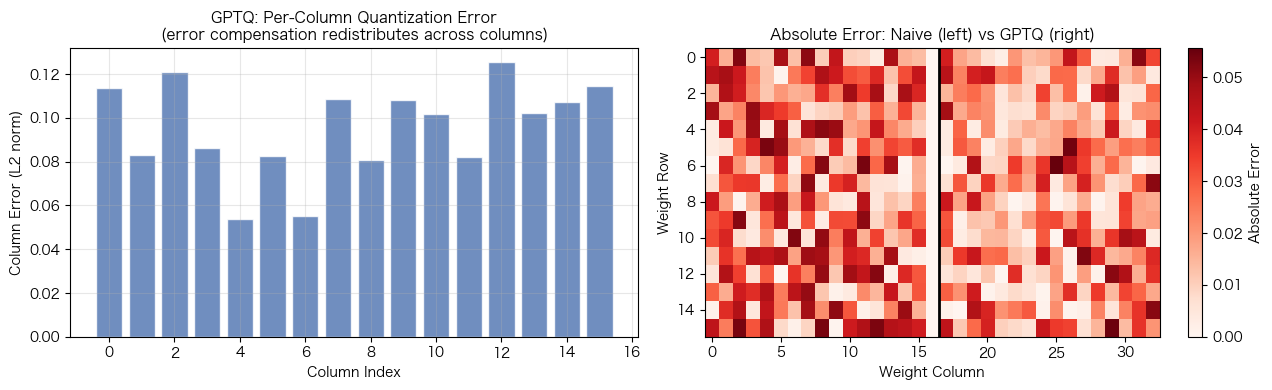

Mean absolute error — Naive: 0.02690, GPTQ: 0.02045
Note: GPTQ may have larger individual weight errors, but minimizes OUTPUT error.


In [9]:
# Visualize per-column quantization error: GPTQ compensates later columns
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Per-column error during GPTQ
axes[0].bar(range(in_features), col_errors, color="#4C72B0", alpha=0.8, edgecolor="white")
axes[0].set_xlabel("Column Index", fontsize=10)
axes[0].set_ylabel("Column Error (L2 norm)", fontsize=10)
axes[0].set_title("GPTQ: Per-Column Quantization Error\n(error compensation redistributes across columns)",
                   fontsize=11, fontweight="bold")
axes[0].grid(True, alpha=0.3)

# Compare weight matrices: original, naive, GPTQ
W_diff_naive = (W - W_naive_deq).abs()
W_diff_gptq = (W - W_gptq).abs()
vmax = max(W_diff_naive.max().item(), W_diff_gptq.max().item())

im = axes[1].imshow(
    torch.cat([W_diff_naive, torch.zeros(out_features, 1), W_diff_gptq], dim=1).numpy(),
    cmap="Reds", aspect="auto", vmin=0, vmax=vmax
)
axes[1].set_title("Absolute Error: Naive (left) vs GPTQ (right)", fontsize=11, fontweight="bold")
axes[1].axvline(x=in_features + 0.5, color="black", linewidth=2)
axes[1].set_xlabel("Weight Column", fontsize=10)
axes[1].set_ylabel("Weight Row", fontsize=10)
plt.colorbar(im, ax=axes[1], label="Absolute Error")

plt.tight_layout()
plt.show()

print(f"Mean absolute error — Naive: {W_diff_naive.mean():.5f}, GPTQ: {W_diff_gptq.mean():.5f}")
print("Note: GPTQ may have larger individual weight errors, but minimizes OUTPUT error.")

**GPTQ 为何有效：** 通过使用 Hessian 矩阵，GPTQ 知道哪些权重是“重要的”（高敏感度）、哪些是“灵活的”（低敏感度）。它将量化误差推向灵活的权重，从而保持整体层输出的精度。这就是为什么 GPTQ 能在数十亿参数的模型上实现近乎无损的 INT4 量化。

---
## 4. AWQ：激活感知的权重量化

**AWQ**（Activation-Aware Weight Quantization，激活感知权重量化）采用了不同的方法。它不是在量化后补偿误差，而是在量化前 **预缩放** 最重要的权重通道。

核心观察：并非所有权重通道同等重要。少数通道承载了大部分激活幅度 —— 这些就是 **显著通道（salient channels）**。显著通道的量化误差会导致不成比例的输出误差。

**AWQ 算法：**
1. 将校准数据通过该层；测量逐通道激活幅度 $s_j = \mathbb{E}[|X_j|]$
2. 识别显著通道（按激活幅度取 top-k）
3. 在量化前将显著权重通道 **放大** 一个因子：$W_j' = W_j \cdot \alpha_j$
4. 将对应激活值 **缩小**：$X_j' = X_j / \alpha_j$
5. 结果：$W'X' = (W \cdot \alpha)(X / \alpha) = WX$ —— 数学上等价，但显著权重现在占据了更多量化范围

In [10]:
# AWQ demo: activation-aware per-channel scaling
torch.manual_seed(42)

out_features, in_features = 32, 16
W = torch.randn(out_features, in_features) * 0.3

# Simulate calibration activations — some channels have much larger magnitude
X_cal = torch.randn(256, in_features)
# Make channels 2, 7, 11 "salient" (much larger activation magnitudes)
X_cal[:, 2] *= 10.0
X_cal[:, 7] *= 8.0
X_cal[:, 11] *= 12.0

# Per-channel activation magnitudes
act_magnitudes = X_cal.abs().mean(dim=0)

print("Per-channel activation magnitudes:")
for i, m in enumerate(act_magnitudes):
    marker = " <-- SALIENT" if m > act_magnitudes.median() * 3 else ""
    print(f"  Channel {i:>2}: {m.item():.3f}{marker}")

Per-channel activation magnitudes:
  Channel  0: 0.749
  Channel  1: 0.709
  Channel  2: 8.677 <-- SALIENT
  Channel  3: 0.838
  Channel  4: 0.732
  Channel  5: 0.733
  Channel  6: 0.833
  Channel  7: 6.513 <-- SALIENT
  Channel  8: 0.821
  Channel  9: 0.851
  Channel 10: 0.789
  Channel 11: 9.158 <-- SALIENT
  Channel 12: 0.751
  Channel 13: 0.865
  Channel 14: 0.868
  Channel 15: 0.774


In [11]:
# AWQ scaling: protect salient channels during quantization
x_test = torch.randn(in_features)
x_test[2] *= 10.0; x_test[7] *= 8.0; x_test[11] *= 12.0  # salient test input
y_exact = W @ x_test

# 1) Naive INT4 quantization
W_q_naive, s_naive = quantize_symmetric(W, bits=4)
W_deq_naive = dequantize_symmetric(W_q_naive, s_naive)
y_naive = W_deq_naive @ x_test

# 2) AWQ-style: compute per-channel scale factors
#    alpha_j = (act_mag_j / act_mag_mean)^0.5 — smooth scaling
alpha = (act_magnitudes / act_magnitudes.mean()).sqrt()
# Clamp to avoid extreme scales
alpha = alpha.clamp(min=0.5, max=5.0)

# Scale weights up by alpha (per input channel), quantize, then scale back
W_scaled = W * alpha.unsqueeze(0)  # scale up salient columns
W_q_awq, s_awq = quantize_symmetric(W_scaled, bits=4)
W_deq_awq = dequantize_symmetric(W_q_awq, s_awq)
W_awq_final = W_deq_awq / alpha.unsqueeze(0)  # scale back down

# Equivalently: compute with scaled input
y_awq = W_awq_final @ x_test

print("=== AWQ vs Naive INT4 ===\n")
print(f"Output RMSE (naive INT4): {(y_exact - y_naive).pow(2).mean().sqrt().item():.4f}")
print(f"Output RMSE (AWQ INT4):   {(y_exact - y_awq).pow(2).mean().sqrt().item():.4f}")
print(f"\nRelative error (naive): {(y_exact - y_naive).norm().item() / y_exact.norm().item():.4%}")
print(f"Relative error (AWQ):   {(y_exact - y_awq).norm().item() / y_exact.norm().item():.4%}")

=== AWQ vs Naive INT4 ===

Output RMSE (naive INT4): 0.5499
Output RMSE (AWQ INT4):   0.6049

Relative error (naive): 12.8530%
Relative error (AWQ):   14.1364%


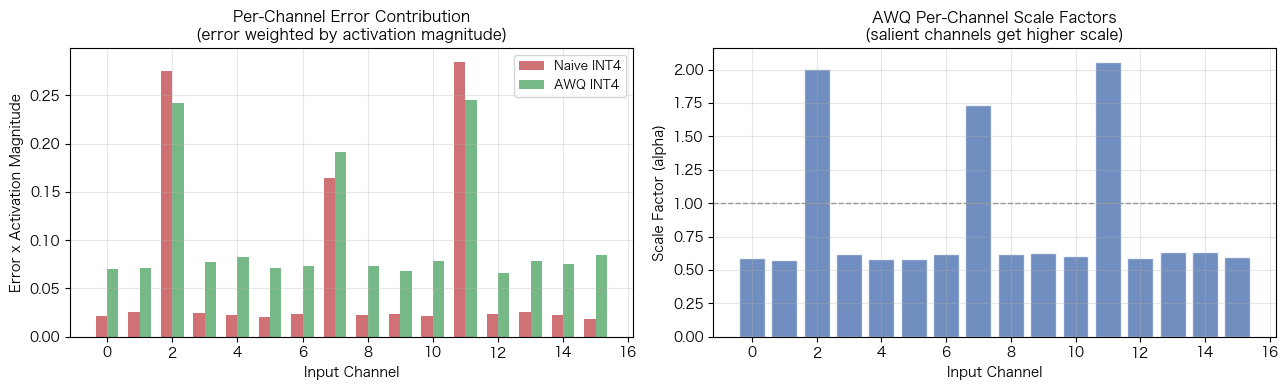

In [12]:
# Visualize AWQ: per-channel error reduction
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Per-channel output error contribution
err_naive_per_ch = (W - W_deq_naive).abs().mean(dim=0) * act_magnitudes
err_awq_per_ch = (W - W_awq_final).abs().mean(dim=0) * act_magnitudes

x_pos = np.arange(in_features)
width = 0.35
axes[0].bar(x_pos - width/2, err_naive_per_ch.detach().numpy(), width,
            label="Naive INT4", color="#C44E52", alpha=0.8)
axes[0].bar(x_pos + width/2, err_awq_per_ch.detach().numpy(), width,
            label="AWQ INT4", color="#55A868", alpha=0.8)
axes[0].set_xlabel("Input Channel", fontsize=10)
axes[0].set_ylabel("Error x Activation Magnitude", fontsize=10)
axes[0].set_title("Per-Channel Error Contribution\n(error weighted by activation magnitude)",
                   fontsize=11, fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Show the scaling factors
axes[1].bar(x_pos, alpha.detach().numpy(), color="#4C72B0", alpha=0.8, edgecolor="white")
axes[1].axhline(y=1.0, color="#999", linewidth=1, linestyle="--")
axes[1].set_xlabel("Input Channel", fontsize=10)
axes[1].set_ylabel("Scale Factor (alpha)", fontsize=10)
axes[1].set_title("AWQ Per-Channel Scale Factors\n(salient channels get higher scale)",
                   fontsize=11, fontweight="bold")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**GPTQ 与 AWQ 的对比：**

| | GPTQ | AWQ |
|---|---|---|
| **策略** | 量化后误差补偿 | 量化前通道缩放 |
| **需要** | 从校准数据计算逆 Hessian 矩阵 | 从校准数据获取激活统计信息 |
| **速度** | 较慢（逐列处理并更新矩阵） | 较快（仅计算缩放因子，然后量化） |
| **精度** | INT4/INT3 下表现优秀 | INT4 下表现优秀，硬件效率略高 |
| **核心洞察** | 将误差重新分配到不敏感的权重 | 通过缩放保护显著通道 |

两者都能实现近乎无损的 LLM INT4 量化，在精度损失极小的情况下将模型大小缩小约 4 倍。

---
## 5. 剪枝基础

**剪枝** 通过将权重设为零来移除神经网络中的权重。这创建了 **稀疏** 权重矩阵，可以更紧凑地存储，并且在硬件支持下可以更高效地计算。

两种主要方法：
- **非结构化剪枝：** 在矩阵任意位置将单个权重置零。灵活性最大，可达到最高稀疏度，但需要稀疏矩阵硬件（如 NVIDIA A100 的 2:4 稀疏张量核心）。
- **结构化剪枝：** 移除整行、整列或整个滤波器。灵活性较低，但产生的密集子矩阵可以在标准硬件上高效运行。

In [13]:
# Magnitude pruning: remove weights with smallest absolute values
torch.manual_seed(42)
W_prune = torch.randn(8, 8) * 0.5

print("Original weight matrix:")
print(W_prune.round(decimals=3))
print(f"\nNon-zero elements: {(W_prune != 0).sum().item()} / {W_prune.nelement()}")

# Prune at different sparsity levels
for sparsity in [0.25, 0.50, 0.75]:
    W_pruned, mask = magnitude_prune(W_prune, sparsity)
    actual_sparsity = 1.0 - mask.float().mean().item()
    err = (W_prune - W_pruned).pow(2).mean().sqrt().item()
    print(f"\nSparsity {sparsity:.0%} -> {mask.sum().item()} non-zeros, RMSE={err:.4f}")
    print(W_pruned.round(decimals=3))

Original weight matrix:
tensor([[ 0.9630,  0.7440,  0.4500, -1.0530,  0.3390, -0.6170, -0.0220, -0.8020],
        [-0.3760,  0.8240, -0.1960, -0.7020, -0.3640, -0.2800, -0.3840,  0.3810],
        [ 0.8210, -0.0800, -0.2490,  0.2200, -0.3790,  0.5390,  0.4000,  0.8400],
        [ 0.6400,  0.6480,  0.3050,  0.6670, -0.1160,  0.0210, -0.1260,  0.4300],
        [-0.6920, -0.4360, -0.1120,  0.8590,  0.1590, -0.2120,  0.1530, -0.3870],
        [-0.7790,  0.4980, -0.4400, -0.3010, -0.6370,  1.0610, -0.6170, -0.2440],
        [-0.4570, -0.3290,  0.0390,  0.2630, -0.2440,  0.5960, -0.4070, -0.3680],
        [-0.7020,  0.0180, -0.0320,  0.3380, -0.0490,  0.9220, -0.5920,  0.6920]])

Non-zero elements: 64 / 64

Sparsity 25% -> 48 non-zeros, RMSE=0.0678
tensor([[ 0.9630,  0.7440,  0.4500, -1.0530,  0.3390, -0.6170, -0.0000, -0.8020],
        [-0.3760,  0.8240, -0.0000, -0.7020, -0.3640, -0.2800, -0.3840,  0.3810],
        [ 0.8210, -0.0000, -0.2490,  0.0000, -0.3790,  0.5390,  0.4000,  0.8400],
  

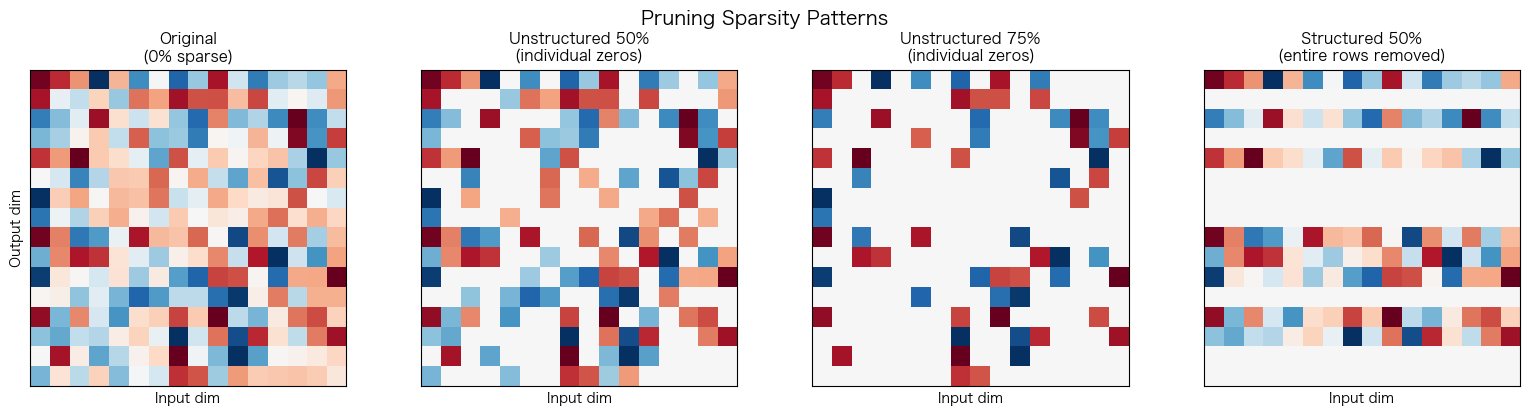

In [14]:
# Visualize: unstructured vs structured pruning sparsity patterns
torch.manual_seed(42)
W_vis = torch.randn(16, 16) * 0.5

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Original
axes[0].imshow(W_vis.numpy(), cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal")
axes[0].set_title("Original\n(0% sparse)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Input dim")
axes[0].set_ylabel("Output dim")

# Unstructured 50%
W_unstruct, mask_u = magnitude_prune(W_vis, sparsity=0.5)
axes[1].imshow(W_unstruct.numpy(), cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal")
axes[1].set_title("Unstructured 50%\n(individual zeros)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Input dim")

# Unstructured 75%
W_unstruct75, mask_u75 = magnitude_prune(W_vis, sparsity=0.75)
axes[2].imshow(W_unstruct75.numpy(), cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal")
axes[2].set_title("Unstructured 75%\n(individual zeros)", fontsize=11, fontweight="bold")
axes[2].set_xlabel("Input dim")

# Structured 50% (remove entire rows)
W_struct, kept_rows = structured_prune_rows(W_vis, sparsity=0.5)
W_struct_full = torch.zeros_like(W_vis)
for new_idx, orig_idx in enumerate(kept_rows):
    W_struct_full[orig_idx] = W_vis[orig_idx]
axes[3].imshow(W_struct_full.numpy(), cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal")
axes[3].set_title("Structured 50%\n(entire rows removed)", fontsize=11, fontweight="bold")
axes[3].set_xlabel("Input dim")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Pruning Sparsity Patterns", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [15]:
# Quantitative comparison: pruning impact on matrix multiplication accuracy
torch.manual_seed(42)
W_test = torch.randn(64, 64) * 0.3
x_test = torch.randn(64, 8)
y_exact = W_test @ x_test

print(f"{'Method':<30} | {'Sparsity':>8} | {'Non-zeros':>9} | {'Output RMSE':>11} | {'Rel Error':>9}")
print("-" * 80)

for sparsity in [0.0, 0.25, 0.5, 0.75, 0.9]:
    # Unstructured
    W_p, mask = magnitude_prune(W_test, sparsity)
    y_p = W_p @ x_test
    rmse = (y_exact - y_p).pow(2).mean().sqrt().item()
    rel = (y_exact - y_p).norm().item() / y_exact.norm().item()
    nz = mask.sum().item()
    print(f"{'Unstructured':<30} | {sparsity:>7.0%} | {nz:>9} | {rmse:>11.5f} | {rel:>8.3%}")

print()
for sparsity in [0.0, 0.25, 0.5, 0.75]:
    # Structured (row pruning)
    W_s, kept = structured_prune_rows(W_test, sparsity)
    W_s_full = torch.zeros_like(W_test)
    W_s_full[kept] = W_test[kept]
    y_s = W_s_full @ x_test
    rmse = (y_exact - y_s).pow(2).mean().sqrt().item()
    rel = (y_exact - y_s).norm().item() / y_exact.norm().item()
    nz = W_s_full.count_nonzero().item()
    print(f"{'Structured (row)':<30} | {sparsity:>7.0%} | {nz:>9} | {rmse:>11.5f} | {rel:>8.3%}")

print("\n-> Unstructured pruning preserves accuracy better at the same sparsity level,")
print("   because it selectively removes the least important individual weights.")
print("-> Structured pruning removes entire rows, which is coarser but GPU-friendly.")

Method                         | Sparsity | Non-zeros | Output RMSE | Rel Error
--------------------------------------------------------------------------------
Unstructured                   |      0% |      4096 |     0.00000 |   0.000%
Unstructured                   |     25% |      3072 |     0.22160 |   9.516%
Unstructured                   |     50% |      2048 |     0.64828 |  27.839%
Unstructured                   |     75% |      1024 |     1.22349 |  52.540%
Unstructured                   |     90% |       410 |     1.73255 |  74.400%

Structured (row)               |      0% |      4096 |     0.00000 |   0.000%
Structured (row)               |     25% |      3072 |     0.95932 |  41.196%
Structured (row)               |     50% |      2048 |     1.57427 |  67.603%
Structured (row)               |     75% |      1024 |     1.99543 |  85.689%

-> Unstructured pruning preserves accuracy better at the same sparsity level,
   because it selectively removes the least important ind

**稀疏度-硬件权衡：** 非结构化剪枝在相同稀疏度下能获得更好的精度，但稀疏矩阵运算难以在 GPU 上加速。结构化剪枝（移除整行/整列/注意力头）产生密集子矩阵，可以直接映射到高效的 GEMM 运算。NVIDIA 的 2:4 结构化稀疏（50% 稀疏度，每 4 个值中恰好有 2 个为零）是一种实用的折中方案，在 Ampere 及更新架构的 GPU 上有专用硬件支持。

---
## 6. 精度-效率权衡

在实践中，模型质量与压缩之间的权衡大致如下：模型质量（以困惑度衡量）在从 32 位降到 16 位再到 8 位时几乎保持不变，然后在低于 4 位时下降更为明显。GPTQ 和 AWQ 等高级方法将这个“拐点”进一步推向更低的比特宽度。

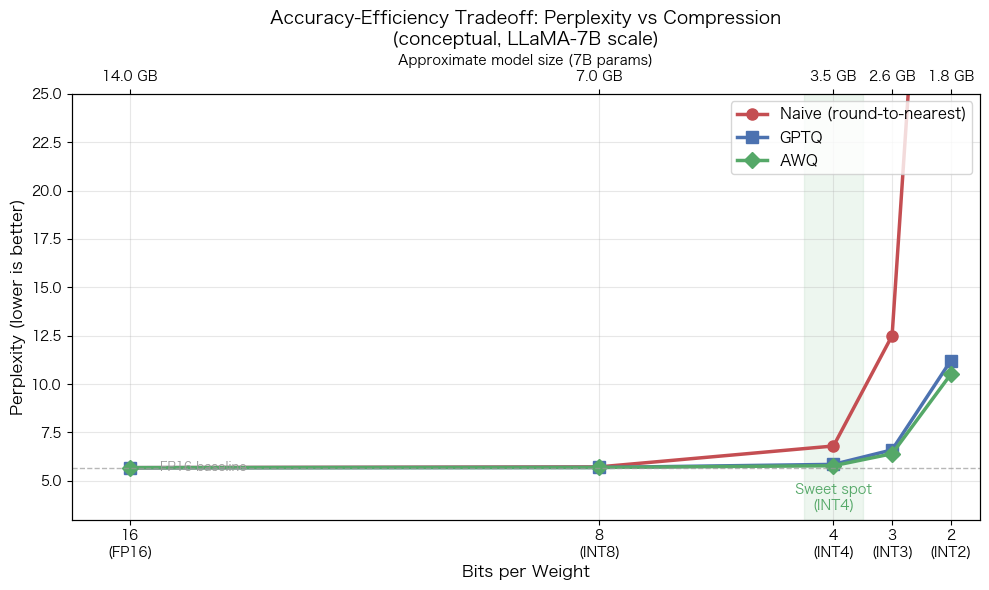

Key takeaway: INT4 with GPTQ or AWQ achieves ~4x compression
with only marginal perplexity increase — the practical sweet spot.


In [16]:
# Conceptual plot: Perplexity vs Bits-per-Weight for different methods
# Values are illustrative of published results on LLaMA-family models

bits_per_weight = [16, 8, 4, 3, 2]

# Conceptual perplexity values (inspired by published LLaMA-7B results)
naive_ppl =  [5.68, 5.72, 6.80, 12.5, 58.0]
gptq_ppl =   [5.68, 5.69, 5.85, 6.60, 11.2]
awq_ppl =    [5.68, 5.69, 5.78, 6.40, 10.5]

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(bits_per_weight, naive_ppl, 'o-', color="#C44E52", linewidth=2.5,
        markersize=8, label="Naive (round-to-nearest)")
ax.plot(bits_per_weight, gptq_ppl, 's-', color="#4C72B0", linewidth=2.5,
        markersize=8, label="GPTQ")
ax.plot(bits_per_weight, awq_ppl, 'D-', color="#55A868", linewidth=2.5,
        markersize=8, label="AWQ")

# FP16 baseline
ax.axhline(y=5.68, color="#999", linewidth=1, linestyle="--", alpha=0.7)
ax.text(15.5, 5.5, "FP16 baseline", fontsize=9, color="#999")

# Annotate the "sweet spot"
ax.axvspan(3.5, 4.5, alpha=0.1, color="#55A868")
ax.text(4.0, 3.5, "Sweet spot\n(INT4)", ha="center", fontsize=10,
        fontweight="bold", color="#55A868")

ax.set_xlabel("Bits per Weight", fontsize=12)
ax.set_ylabel("Perplexity (lower is better)", fontsize=12)
ax.set_title("Accuracy-Efficiency Tradeoff: Perplexity vs Compression\n(conceptual, LLaMA-7B scale)",
             fontsize=13, fontweight="bold")
ax.set_xlim(17, 1.5)  # reversed x-axis: more compressed to the right
ax.set_ylim(3, 25)
ax.legend(fontsize=11, loc="upper right")
ax.grid(True, alpha=0.3)
ax.set_xticks(bits_per_weight)
ax.set_xticklabels(["16\n(FP16)", "8\n(INT8)", "4\n(INT4)", "3\n(INT3)", "2\n(INT2)"])

# Add memory axis on top
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(bits_per_weight)
model_gb = [7 * b / 8 for b in bits_per_weight]  # 7B params
ax2.set_xticklabels([f"{g:.1f} GB" for g in model_gb])
ax2.set_xlabel("Approximate model size (7B params)", fontsize=10)

plt.tight_layout()
plt.show()

print("Key takeaway: INT4 with GPTQ or AWQ achieves ~4x compression")
print("with only marginal perplexity increase — the practical sweet spot.")

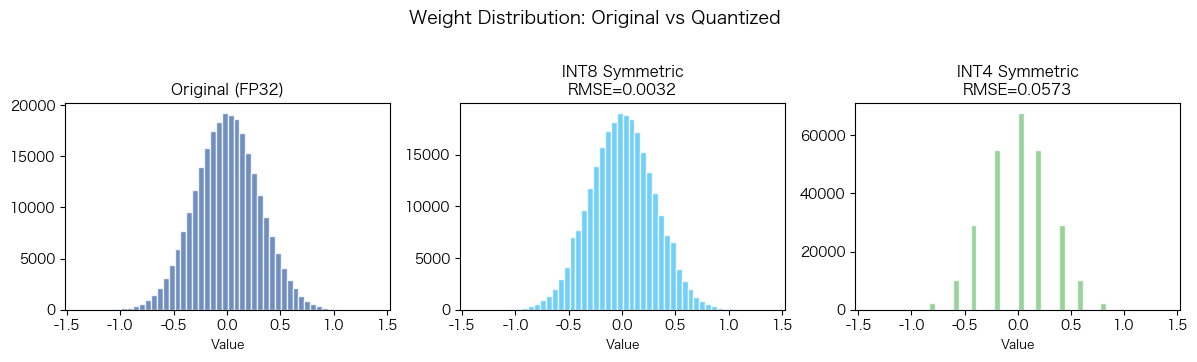

In [17]:
# Use the helper to draw side-by-side quantization comparison histograms
torch.manual_seed(42)
W_demo = torch.randn(512, 512) * 0.3

W_q8, s8 = quantize_symmetric(W_demo, bits=8)
W_q4, s4 = quantize_symmetric(W_demo, bits=4)

fig, axes = draw_quantization_comparison(
    W_demo.flatten(),
    {
        "INT8 Symmetric": dequantize_symmetric(W_q8, s8).flatten(),
        "INT4 Symmetric": dequantize_symmetric(W_q4, s4).flatten(),
    },
    title="Weight Distribution: Original vs Quantized"
)
plt.show()

---
## 总结

| 技术 | 核心思想 | 压缩比 | 精度影响 |
|-----------|----------|-------------|-----------------|
| **对称量化** | 将权重映射到 $[-2^{b-1}, 2^{b-1}-1]$，使用单一 scale 因子 | 2-8x | INT8 低影响，INT4 中等影响 |
| **非对称量化** | 增加 zero-point 偏移以适应非对称分布 | 2-8x | 对偏斜数据优于对称量化 |
| **GPTQ** | 逐列量化，基于 Hessian 矩阵的误差补偿 | 4-8x | INT4 下近乎无损 |
| **AWQ** | 预缩放显著通道以在量化中保护它们 | 4-8x | INT4 下近乎无损，校准速度快 |
| **非结构化剪枝** | 将幅度最小的单个权重置零 | 2-10x | 50-80% 稀疏度下表现良好 |
| **结构化剪枝** | 移除整行/整列/注意力头 | 1.5-4x | 粒度较粗但对硬件友好 |

**实践建议：**
- **LLM 服务部署**：使用 GPTQ 或 AWQ 的 INT4 量化是当前的最佳选择 —— 缩小 4 倍，质量损失极小
- **边缘设备部署**：结合量化 + 剪枝以获得最大压缩比
- **硬件很重要**：INT8 在大多数 GPU 上有原生支持；INT4 需要专用 kernel；稀疏运算需要 Ampere+ GPU

### 延伸阅读
- [GPTQ: Accurate Post-Training Quantization (Frantar et al., 2023)](https://arxiv.org/abs/2210.17323)
- [AWQ: Activation-aware Weight Quantization (Lin et al., 2023)](https://arxiv.org/abs/2306.00978)
- [SparseGPT: Massive Language Models Can be Accurately Pruned in One-Shot (Frantar & Alistarh, 2023)](https://arxiv.org/abs/2301.00774)
- 下一个 notebook：**[06-speculative-decoding](06-speculative-decoding.ipynb)** —— 每次前向传播生成多个 token